# 📚 Algoritmos e Estruturas de Dados

`Programação` · **Engenharia da Computação** · `Python 3`

> **Pilhas, filas, listas, árvores, busca, ordenação e complexidade.**

Estruturas de dados clássicas e análise de complexidade: pilha, fila, lista ligada, árvore binária, busca binária e comparação de algoritmos de ordenação.



## 📚 Conteúdo da matéria

Resumo teórico organizado em cards (o mesmo que é renderizado no PDF gerado abaixo).

### 🟢 ESTRUTURAS LINEARES

**Ideia:** Organizar dados em sequência para acesso, inserção, remoção e processamento.

- Array: acesso por índice; tamanho lógico previsível
- Lista ligada: nós + ponteiros; inserção/remoção local eficiente
- Pilha: LIFO → push, pop, top
- Fila: FIFO → enqueue, dequeue, front
- Deque: inserção/remoção nas duas extremidades
- Array: busca O(1) por índice; inserção interna custa deslocamento
- Lista: acesso sequencial O(n); não desloca elementos
- Escolha: depende de acesso aleatório vs inserções frequentes

> 💡 **Dica:** Se precisa acessar por posição rapidamente, prefira array. Se vai inserir/remover muito no meio, pense em lista ligada.

### 🟢 BUSCA, ORDENAÇÃO & COMPLEXIDADE

**Ideia:** Comparar algoritmos pelo custo de tempo e memória para escolher a melhor solução.

- Big-O: limite superior assintótico do crescimento
- Busca linear: O(n)
- Busca binária: O(log n), exige vetor ordenado
- Bubble/Selection/Insertion: O(n²)
- Merge sort: O(n log n), estável
- Quick sort: médio O(n log n), pior O(n²)
- Espaço: analisar memória além do tempo
- Trade-off: melhor caso, pior caso e caso médio importam

> 💡 **Dica:** Antes de otimizar código, identifique o gargalo. Trocar O(n²) por O(n log n) costuma valer mais que micro-otimizações.

### 🟢 RECURSÃO, ÁRVORES & GRAFOS

**Ideia:** Modelar hierarquias e conexões, explorando problemas por divisão em subproblemas.

- Recursão: caso base + chamada recursiva menor
- Pilha de execução: cada chamada guarda estado
- Árvore: raiz, nós, folhas, altura e subárvores
- Percursos: pré-ordem, em-ordem, pós-ordem, largura
- BST: esquerda < raiz < direita
- Grafo: Vértices + arestas; pode ser dirigido ou não
- Busca: DFS usa profundidade; BFS usa fila e níveis
- Aplicações: arquivos, redes, caminhos e dependências

> 💡 **Dica:** Toda recursão precisa de caso base claro. Para percorrer níveis, BFS costuma ser a escolha natural; para profundidade, DFS.

### 🟢 HASH, HEAPS & BOAS PRÁTICAS

**Ideia:** Acelerar consultas e organizar prioridades usando estruturas adequadas ao problema.

- Tabela hash: chave → índice por função hash
- Colisão: pode usar encadeamento ou endereçamento aberto
- Custo médio: busca/inserção/rem. ≈ O(1)
- Heap: árvore quase completa com propriedade de prioridade
- Max-heap: pai ≥ filhos; min-heap: pai ≤ filhos
- Fila de prioridade: inserção e remoção O(log n)
- ADT: separar interface da implementação
- Boas práticas: modularizar, testar e documentar invariantes

> 💡 **Dica:** Estrutura boa depende da operação dominante: consulta rápida pede hash; retirar maior/menor repetidamente pede heap.


## ⚙️ Gerador do Cheat Sheet (PDF)

O script original gera um **PDF estilo OneNote** com `reportlab`. Para rodar em qualquer sistema operacional, as fontes são resolvidas automaticamente (usa a **DejaVu embarcada no matplotlib** com fallback para os caminhos clássicos de Windows/Linux/macOS) e o arquivo de saída é gerado na pasta atual.


In [1]:
from pathlib import Path
import matplotlib as _mpl

def _dejavu_dir():
    _base = Path(_mpl.__file__).parent / "mpl-data" / "fonts" / "ttf"
    if (_base / "DejaVuSans.ttf").exists():
        return str(_base)
    for _p in [Path("/usr/share/fonts/truetype/dejavu"),
               Path("/System/Library/Fonts"),
               Path("/Library/Fonts"),
               Path("C:/Windows/Fonts")]:
        if (_p / "DejaVuSans.ttf").exists():
            return str(_p)
    raise RuntimeError("Fonte DejaVuSans nao encontrada; instale matplotlib ou a fonte DejaVu.")


# ===== código original adaptado =====
import math
from pathlib import Path

from reportlab.lib.colors import HexColor
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.styles import ParagraphStyle
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.pdfgen import canvas
from reportlab.platypus import Paragraph

OUT = Path('Algoritmos_Estrutura_Dados.pdf')
PAGE_W, PAGE_H = landscape(A4)
MARGIN = 16

# ---------- fonts ----------
FONT_DIR = Path(_dejavu_dir())
pdfmetrics.registerFont(TTFont('DVCond', str(FONT_DIR / 'DejaVuSans.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Bold', str(FONT_DIR / 'DejaVuSans-Bold.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Oblique', str(FONT_DIR / 'DejaVuSans-Oblique.ttf')))
pdfmetrics.registerFontFamily(
    'DVCond',
    normal='DVCond',
    bold='DVCond-Bold',
    italic='DVCond-Oblique',
    boldItalic='DVCond-Bold',
)

# ---------- palette ----------
BG = HexColor('#F6F8FB')
GRID = HexColor('#E6EBF3')
INK = HexColor('#1C2B4A')
MUTED = HexColor('#5A6B8C')
WHITE = HexColor('#FFFFFF')
LINE = HexColor('#E7ECF4')
AXIS = HexColor('#D7DEEA')

TEAL, TEAL_T = HexColor('#147D82'), HexColor('#E3F2F1')
AMBER, AMBER_T = HexColor('#C97A1A'), HexColor('#FBEDDD')
BERRY, BERRY_T = HexColor('#A83E63'), HexColor('#F6E4EB')
GREEN, GREEN_T = HexColor('#2F7A4F'), HexColor('#E2F0E7')

CARDS = [
    {
        'title': 'ESTRUTURAS LINEARES',
        'color': TEAL,
        'tint': TEAL_T,
        'kind': 'lineares',
        'idea': 'Organizar dados em sequência para acesso, inserção, remoção e processamento.',
        'formulas': [
            '<b>Array:</b> acesso por índice; tamanho lógico previsível',
            '<b>Lista ligada:</b> nós + ponteiros; inserção/remoção local eficiente',
            '<b>Pilha:</b> LIFO → push, pop, top',
            '<b>Fila:</b> FIFO → enqueue, dequeue, front',
            '<b>Deque:</b> inserção/remoção nas duas extremidades',
            '<b>Array:</b> busca O(1) por índice; inserção interna custa deslocamento',
            '<b>Lista:</b> acesso sequencial O(n); não desloca elementos',
            '<b>Escolha:</b> depende de acesso aleatório vs inserções frequentes',
        ],
        'tip': 'Se precisa acessar por posição rapidamente, prefira array. Se vai inserir/remover muito no meio, pense em lista ligada.',
    },
    {
        'title': 'BUSCA, ORDENAÇÃO<br/>&amp; COMPLEXIDADE',
        'color': AMBER,
        'tint': AMBER_T,
        'kind': 'complexidade',
        'idea': 'Comparar algoritmos pelo custo de tempo e memória para escolher a melhor solução.',
        'formulas': [
            '<b>Big-O:</b> limite superior assintótico do crescimento',
            '<b>Busca linear:</b> O(n)',
            '<b>Busca binária:</b> O(log n), exige vetor ordenado',
            '<b>Bubble/Selection/Insertion:</b> O(n²)',
            '<b>Merge sort:</b> O(n log n), estável',
            '<b>Quick sort:</b> médio O(n log n), pior O(n²)',
            '<b>Espaço:</b> analisar memória além do tempo',
            '<b>Trade-off:</b> melhor caso, pior caso e caso médio importam',
        ],
        'tip': 'Antes de otimizar código, identifique o gargalo. Trocar O(n²) por O(n log n) costuma valer mais que micro-otimizações.',
    },
    {
        'title': 'RECURSÃO, ÁRVORES<br/>&amp; GRAFOS',
        'color': BERRY,
        'tint': BERRY_T,
        'kind': 'arvores',
        'idea': 'Modelar hierarquias e conexões, explorando problemas por divisão em subproblemas.',
        'formulas': [
            '<b>Recursão:</b> caso base + chamada recursiva menor',
            '<b>Pilha de execução:</b> cada chamada guarda estado',
            '<b>Árvore:</b> raiz, nós, folhas, altura e subárvores',
            '<b>Percursos:</b> pré-ordem, em-ordem, pós-ordem, largura',
            '<b>BST:</b> esquerda &lt; raiz &lt; direita',
            '<b>Grafo:</b> Vértices + arestas; pode ser dirigido ou não',
            '<b>Busca:</b> DFS usa profundidade; BFS usa fila e níveis',
            '<b>Aplicações:</b> arquivos, redes, caminhos e dependências',
        ],
        'tip': 'Toda recursão precisa de caso base claro. Para percorrer níveis, BFS costuma ser a escolha natural; para profundidade, DFS.',
    },
    {
        'title': 'HASH, HEAPS<br/>&amp; BOAS PRÁTICAS',
        'color': GREEN,
        'tint': GREEN_T,
        'kind': 'hash',
        'idea': 'Acelerar consultas e organizar prioridades usando estruturas adequadas ao problema.',
        'formulas': [
            '<b>Tabela hash:</b> chave → índice por função hash',
            '<b>Colisão:</b> pode usar encadeamento ou endereçamento aberto',
            '<b>Custo médio:</b> busca/inserção/rem. ≈ O(1)',
            '<b>Heap:</b> árvore quase completa com propriedade de prioridade',
            '<b>Max-heap:</b> pai ≥ filhos; <b>min-heap:</b> pai ≤ filhos',
            '<b>Fila de prioridade:</b> inserção e remoção O(log n)',
            '<b>ADT:</b> separar interface da implementação',
            '<b>Boas práticas:</b> modularizar, testar e documentar invariantes',
        ],
        'tip': 'Estrutura boa depende da operação dominante: consulta rápida pede hash; retirar maior/menor repetidamente pede heap.',
    },
]

# ---------- layout ----------
CARD_TOP = PAGE_H - 16
CARD_BOTTOM = 16
CARD_H = CARD_TOP - CARD_BOTTOM
GAP = 14
CARD_W = (PAGE_W - 2 * MARGIN - 3 * GAP) / 4

STYLE_TITLE = ParagraphStyle(
    'card_title',
    fontName='DVCond-Bold',
    fontSize=17.2,
    leading=18.6,
    textColor=WHITE,
    alignment=1,
    spaceAfter=0,
)
STYLE_IDEA = ParagraphStyle(
    'idea',
    fontName='DVCond-Oblique',
    fontSize=12.6,
    leading=15.6,
    textColor=MUTED,
)
STYLE_TIP = ParagraphStyle(
    'tip',
    fontName='DVCond',
    fontSize=11.7,
    leading=14.7,
    textColor=INK,
)


def arrow(c, x1, y1, x2, y2, color, width=1.2, head=5):
    c.setStrokeColor(color)
    c.setFillColor(color)
    c.setLineWidth(width)
    c.line(x1, y1, x2, y2)
    ang = math.atan2(y2 - y1, x2 - x1)
    for delta in (2.55, -2.55):
        c.line(x2, y2, x2 + head * math.cos(ang + delta), y2 + head * math.sin(ang + delta))


def box(c, x, y, w, h, color, label=None, fill=False):
    c.setStrokeColor(color)
    c.setFillColor(HexColor('#F8FAFD') if fill else WHITE)
    c.setLineWidth(1.2)
    c.roundRect(x, y, w, h, 2, stroke=1, fill=1 if fill else 0)
    if label:
        c.setFillColor(INK)
        c.setFont('DVCond-Bold', 8.5)
        c.drawCentredString(x + w/2, y + h/2 - 3, label)


def diagram_lineares(c, ox, oy, dw, dh, color):
    # array/list on top
    y = oy + dh * 0.62
    start = ox + dw * 0.08
    for i, label in enumerate(['0', '1', '2', '3']):
        box(c, start + i*28, y, 24, 16, color)
        c.setFillColor(MUTED)
        c.setFont('DVCond', 7.6)
        c.drawCentredString(start + i*28 + 12, y - 9, label)
    # stack and queue below
    sx = ox + dw*0.10
    sy = oy + dh*0.16
    for i in range(3):
        box(c, sx, sy + i*14, 30, 12, color)
    c.setFillColor(INK)
    c.setFont('DVCond-Bold', 9)
    c.drawString(sx-2, sy + 46, 'Pilha')
    qx = ox + dw*0.56
    qy = oy + dh*0.28
    for i in range(4):
        box(c, qx + i*22, qy, 18, 14, color)
    arrow(c, qx - 16, qy+7, qx - 2, qy+7, color, 1.0, 3.5)
    arrow(c, qx + 88, qy+7, qx + 102, qy+7, color, 1.0, 3.5)
    c.setFillColor(INK)
    c.setFont('DVCond-Bold', 9)
    c.drawString(qx + 18, qy + 22, 'Fila')


def curve_plot(c, ox, oy, dw, dh, color):
    c.setStrokeColor(AXIS)
    c.setLineWidth(0.8)
    c.line(ox, oy, ox + dw, oy)
    c.line(ox, oy, ox, oy + dh)
    # O(log n)
    p = c.beginPath()
    p.moveTo(ox + 4, oy + 8)
    p.curveTo(ox + dw*0.18, oy + dh*0.18, ox + dw*0.40, oy + dh*0.34, ox + dw*0.82, oy + dh*0.46)
    c.setStrokeColor(color)
    c.setLineWidth(1.4)
    c.drawPath(p, stroke=1, fill=0)
    # O(n)
    c.setStrokeColor(INK)
    c.line(ox + 4, oy + 6, ox + dw*0.82, oy + dh*0.70)
    # O(n²)
    p2 = c.beginPath()
    p2.moveTo(ox + 4, oy + 5)
    p2.curveTo(ox + dw*0.25, oy + dh*0.04, ox + dw*0.45, oy + dh*0.24, ox + dw*0.72, oy + dh*0.86)
    c.setStrokeColor(BERRY)
    c.drawPath(p2, stroke=1, fill=0)


def diagram_complexidade(c, ox, oy, dw, dh, color):
    curve_plot(c, ox + dw*0.08, oy + dh*0.12, dw*0.58, dh*0.68, color)
    c.setFillColor(MUTED)
    c.setFont('DVCond-Bold', 8.5)
    c.drawString(ox + dw*0.69, oy + dh*0.63, 'O(n²)')
    c.drawString(ox + dw*0.63, oy + dh*0.46, 'O(n)')
    c.drawString(ox + dw*0.63, oy + dh*0.30, 'O(log n)')


def diagram_arvores(c, ox, oy, dw, dh, color):
    # tree left
    nodes = {
        'r': (ox + dw*0.26, oy + dh*0.68),
        'a': (ox + dw*0.16, oy + dh*0.46),
        'b': (ox + dw*0.36, oy + dh*0.46),
        'c': (ox + dw*0.10, oy + dh*0.26),
        'd': (ox + dw*0.22, oy + dh*0.26),
    }
    c.setStrokeColor(color)
    c.setLineWidth(1.2)
    for u,v in [('r','a'),('r','b'),('a','c'),('a','d')]:
        c.line(nodes[u][0], nodes[u][1], nodes[v][0], nodes[v][1])
    for x,y in nodes.values():
        c.circle(x, y, 6, stroke=1, fill=0)
    # graph right
    pts = [(ox + dw*0.66, oy + dh*0.64), (ox + dw*0.82, oy + dh*0.58), (ox + dw*0.76, oy + dh*0.34), (ox + dw*0.60, oy + dh*0.34)]
    for i,j in [(0,1),(1,2),(2,3),(3,0),(0,2)]:
        c.line(pts[i][0], pts[i][1], pts[j][0], pts[j][1])
    for x,y in pts:
        c.circle(x, y, 5, stroke=1, fill=0)


def diagram_hash(c, ox, oy, dw, dh, color):
    # hash table left
    tx = ox + dw*0.12
    ty = oy + dh*0.22
    for i,lab in enumerate(['0','1','2','3']):
        box(c, tx, ty + i*16, 22, 14, color, lab)
    c.setFillColor(MUTED)
    c.setFont('DVCond-Bold', 8.5)
    c.drawString(tx + 34, ty + 52, 'k → h(k)')
    arrow(c, tx + 58, ty + 50, tx + 90, ty + 50, color, 1.0, 3.5)
    # heap right
    pts = [(ox + dw*0.70, oy + dh*0.66), (ox + dw*0.62, oy + dh*0.46), (ox + dw*0.78, oy + dh*0.46), (ox + dw*0.58, oy + dh*0.28), (ox + dw*0.66, oy + dh*0.28)]
    for u,v in [(0,1),(0,2),(1,3),(1,4)]:
        c.line(pts[u][0], pts[u][1], pts[v][0], pts[v][1])
    for x,y in pts:
        c.circle(x,y,6,stroke=1,fill=0)


DIAGRAMS = {
    'lineares': diagram_lineares,
    'complexidade': diagram_complexidade,
    'arvores': diagram_arvores,
    'hash': diagram_hash,
}


def draw_card(c, card, cx):
    color, tint = card['color'], card['tint']

    c.setFillColor(WHITE)
    c.setStrokeColor(color)
    c.setLineWidth(1.5)
    c.roundRect(cx, CARD_BOTTOM, CARD_W, CARD_H, 10, fill=1, stroke=1)

    header_h = 58
    header_y = CARD_TOP - 7 - header_h
    c.setFillColor(color)
    c.roundRect(cx + 5, header_y, CARD_W - 10, header_h, 6, fill=1, stroke=0)
    title = Paragraph(card['title'], STYLE_TITLE)
    _, title_h = title.wrapOn(c, CARD_W - 22, header_h - 6)
    title.drawOn(c, cx + 11, header_y + (header_h - title_h) / 2)

    cursor = header_y - 11

    diagram_h = 76
    diagram_y = cursor - diagram_h
    DIAGRAMS[card['kind']](c, cx + 11, diagram_y, CARD_W - 22, diagram_h, color)
    cursor = diagram_y - 10

    idea = Paragraph(card['idea'], STYLE_IDEA)
    _, idea_h = idea.wrapOn(c, CARD_W - 22, 70)
    idea.drawOn(c, cx + 11, cursor - idea_h)
    cursor -= idea_h + 9

    c.setStrokeColor(LINE)
    c.setLineWidth(0.8)
    c.line(cx + 11, cursor, cx + CARD_W - 11, cursor)
    cursor -= 10

    tip_y = CARD_BOTTOM + 8
    tip = Paragraph('<b>Dica:</b> ' + card['tip'], STYLE_TIP)
    _, tip_text_h = tip.wrapOn(c, CARD_W - 34, 130)
    tip_h = max(72, tip_text_h + 22)
    tip_top = tip_y + tip_h

    formula_html = '<br/>'.join('• ' + item for item in card['formulas'])
    available_h = cursor - tip_top - 10
    font_size = 10.95
    leading = 13.85
    while True:
        style_formula = ParagraphStyle(
            'formula_' + card['kind'],
            fontName='DVCond',
            fontSize=font_size,
            leading=leading,
            textColor=INK,
        )
        formulas = Paragraph(formula_html, style_formula)
        _, formula_h = formulas.wrapOn(c, CARD_W - 22, 470)
        if formula_h <= available_h or font_size <= 10.0:
            break
        font_size -= 0.1
        leading -= 0.1

    formulas.drawOn(c, cx + 11, cursor - formula_h)

    c.setFillColor(tint)
    c.roundRect(cx + 7, tip_y, CARD_W - 14, tip_h, 6, fill=1, stroke=0)
    tip.drawOn(c, cx + 17, tip_y + (tip_h - tip_text_h) / 2)


c = canvas.Canvas(str(OUT), pagesize=landscape(A4))
c.setTitle('Algoritmos e Estrutura de Dados - Cheat Sheet OneNote')
c.setAuthor('OpenAI')

# Background grid
c.setFillColor(BG)
c.rect(0, 0, PAGE_W, PAGE_H, fill=1, stroke=0)
c.setStrokeColor(GRID)
c.setLineWidth(0.35)
step = 16
x = 0
while x < PAGE_W:
    c.line(x, 0, x, PAGE_H)
    x += step
y = 0
while y < PAGE_H:
    c.line(0, y, PAGE_W, y)
    y += step

x = MARGIN
for card in CARDS:
    draw_card(c, card, x)
    x += CARD_W + GAP

c.save()
print(f'PDF gerado em {OUT}')


PDF gerado em Algoritmos_Estrutura_Dados.pdf


## 🖼️ Resultado visual

As páginas do PDF gerado são renderizadas abaixo (código de pré-visualização). Este é o **cheat sheet** da matéria.


Páginas: 1


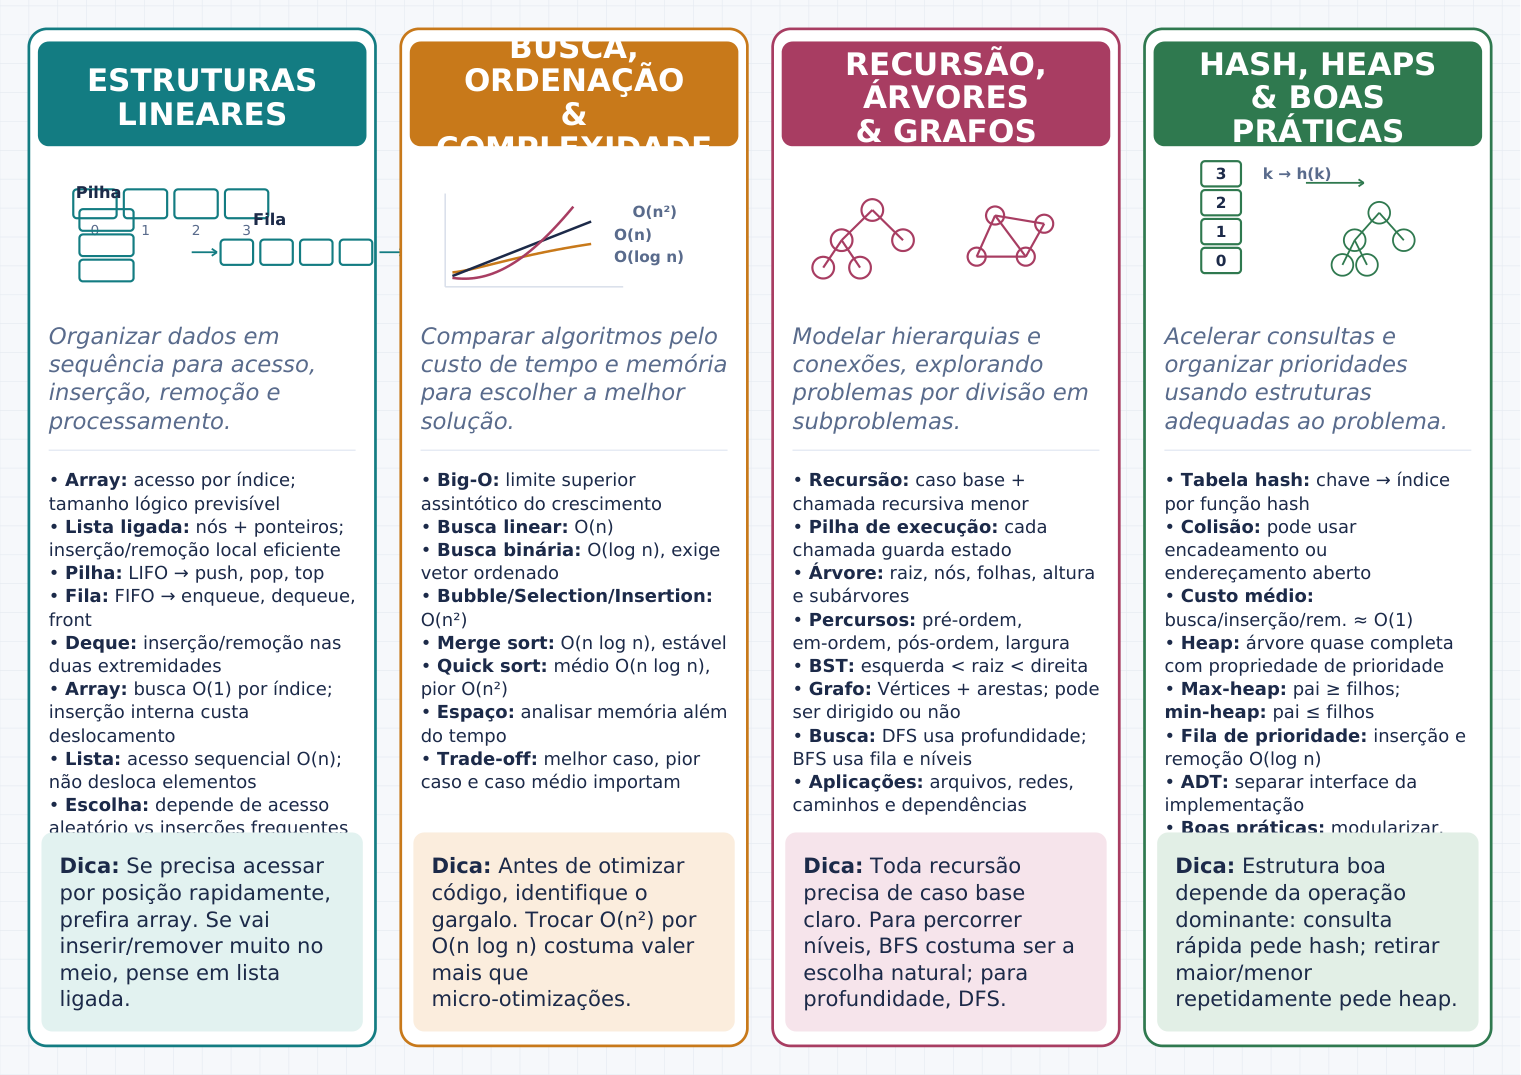

In [2]:
import pymupdf as fitz
from IPython.display import display, Image

doc = fitz.open(Path('Algoritmos_Estrutura_Dados.pdf'))
print(f'Páginas: {len(doc)}')
for i, page in enumerate(doc, 1):
    pix = page.get_pixmap(dpi=130)
    display(Image(data=pix.tobytes('png')))


## 🎯 Exemplos práticos

Código executável que demonstra os conceitos da matéria com **saídas reais** (cálculos, simulações e gráficos).


In [3]:

import time
import random
from collections import deque

print("=" * 60)
print("1) PILHA (LIFO) e FILA (FIFO)")
pilha, fila = [], deque()
for x in "ABCD":
    pilha.append(x); fila.append(x)
print(f"   pilha: {[pilha.pop() for _ in range(len(pilha))]} (ultimo a entrar, primeiro a sair)")
print(f"   fila : {[fila.popleft() for _ in range(len(fila))]} (primeiro a entrar, primeiro a sair)")

print("\n2) LISTA LIGADA simples")
class No:
    def __init__(self, val): self.val, self.prox = val, None
class ListaLigada:
    def __init__(self): self.head = None
    def inserir(self, v):
        no = No(v); no.prox = self.head; self.head = no
    def percorrer(self):
        r, at = [], self.head
        while at: r.append(at.val); at = at.prox
        return r
    def buscar(self, v):
        at, pos = self.head, 0
        while at:
            if at.val == v: return pos
            at, pos = at.prox, pos + 1
        return -1
ll = ListaLigada()
for x in (3, 7, 1, 9): ll.inserir(x)
print(f"   lista: {ll.percorrer()} | buscar(7) na posicao {ll.buscar(7)}")

print("\n3) ARVORE BINARIA - percurso em ordem")
class NoArv:
    def __init__(self, v): self.v, self.e, self.d = v, None, None
def insere(no, v):
    if no is None: return NoArv(v)
    if v < no.v: no.e = insere(no.e, v)
    else: no.d = insere(no.d, v)
    return no
def em_ordem(no, out):
    if no: em_ordem(no.e, out); out.append(no.v); em_ordem(no.d, out)
raiz = None
for v in (50, 30, 70, 20, 40, 60, 80): raiz = insere(raiz, v)
o = []; em_ordem(raiz, o)
print(f"   em-ordem (sai ordenado): {o}")

print("\n4) BUSCA BINARIA em vetor ordenado (O(log n))")
vet = sorted(random.sample(range(1, 1000), 200))
def busca_binaria(v, alvo):
    lo, hi = 0, len(v) - 1
    passos = 0
    while lo <= hi:
        passos += 1
        mid = (lo + hi)//2
        if v[mid] == alvo: return mid, passos
        if v[mid] < alvo: lo = mid + 1
        else: hi = mid - 1
    return -1, passos
alvo = vet[57]
pos, passos = busca_binaria(vet, alvo)
print(f"   vetor com {len(vet)} itens -> encontrou {alvo} na pos {pos} em {passos} passos")

print("\n5) COMPLEXIDADE: ordenacao O(n^2) vs O(n log n)")
def bubble_sort(a):
    for i in range(len(a)):
        for j in range(len(a)-1-i):
            if a[j] > a[j+1]: a[j], a[j+1] = a[j+1], a[j]
    return a
random.seed(2)
tam = 3000
arr1 = [random.random() for _ in range(tam)]
arr2 = arr1[:]
t0 = time.perf_counter(); bubble_sort(arr1); t1 = time.perf_counter()
arr2.sort(); t2 = time.perf_counter()
print(f"   bubble sort (O(n^2)): {(t1-t0)*1000:.1f} ms")
print(f"   timsort    (O(nlogn)): {(t2-t1)*1000:.2f} ms")
print("\nOK - estruturas e complexidade demonstradas.")


1) PILHA (LIFO) e FILA (FIFO)
   pilha: ['D', 'C', 'B', 'A'] (ultimo a entrar, primeiro a sair)
   fila : ['A', 'B', 'C', 'D'] (primeiro a entrar, primeiro a sair)

2) LISTA LIGADA simples
   lista: [9, 1, 7, 3] | buscar(7) na posicao 2

3) ARVORE BINARIA - percurso em ordem
   em-ordem (sai ordenado): [20, 30, 40, 50, 60, 70, 80]

4) BUSCA BINARIA em vetor ordenado (O(log n))
   vetor com 200 itens -> encontrou 269 na pos 57 em 8 passos

5) COMPLEXIDADE: ordenacao O(n^2) vs O(n log n)


   bubble sort (O(n^2)): 1183.0 ms
   timsort    (O(nlogn)): 0.66 ms

OK - estruturas e complexidade demonstradas.


## 🚀 Como executar

1. Instale as dependências: `pip install -r requirements.txt`
2. Abra este notebook no Jupyter (`jupyter notebook`) ou VS Code.
3. Execute as células em ordem (`Run All`).

> 💡 O notebook foi **pré-executado**: as saídas já estão embutidas, mas você pode rodar novamente para reproduzir.
